In [34]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

# **Building and Modelling Parameters**

### **Task 1: Power Splitting at a Partially Reflective Mirror**

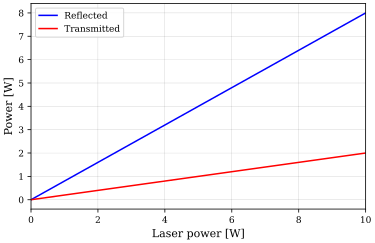

In [9]:
finesse.configure(plotting=True)
kat = finesse.Model()

#the model setup
kat.parse("""

    l L0 10                      #Laser with power = 10W
    s s1 L0.p1 m1.p1 L=1         #space between the laser and mirror L = 1m
    m m1 R=0.8 T=0.2 phi=0       #Mirror
    pd pd1 m1.p1.o               #measure reflected power
    pd pd2 m1.p2.o               #measure transmitted power
""")
out = kat.run(Xaxis('L0.P', 'lin', 0, 10, 50))
plt.plot(out.x1, out['pd1'], label='Reflected')
plt.plot(out.x1, out['pd2'], label='Transmitted')
plt.xlabel('Laser power [W]')
plt.ylabel('Power [W]')
plt.legend()
plt.show()

In [10]:
finesse.configure(plotting=True)
kat = finesse.Model()

kat.parse("""

    l L0 10
    s s1 L0.p1 m1.p1 L=1
    m m1 R=0.8 T=0.2 phi=0
    pd pd1 m1.p1.o
    pd pd2 m1.p2.o
""")
out = kat.run()
print("Reflected power:", out['pd1'])
print("Transmitted power:", out['pd2'])

print("Total output:", out['pd1'] + out['pd2'])

Reflected power: 8.0
Transmitted power: 2.0
Total output: 10.0


### **Task 2: Analysis of Amplitude and Phase**

In [8]:
finesse.configure(plotting=True)

kat = finesse.Model()
kat.parse("""
    l L0 10
    s s1 L0.p1 m1.p1 L=1
    m m1 R=0.8 T=0.2 phi=0

    ad Ain   m1.p1.i 0
    ad Arefl m1.p1.o 0
    ad Atran m1.p2.o 0
""")

out = kat.run()

Ein   = out['Ain']
Erefl = out['Arefl']
Etran = out['Atran']

print(f"Incident  : |E| = {np.abs(Ein):.2f} sqrt(W),  phase = {np.angle(Ein, deg=True):.1f} deg")
print(f"Reflected : |E| = {np.abs(Erefl):.2f} sqrt(W), phase = {np.angle(Erefl, deg=True):.1f} deg")
print(f"Transmitted: |E| = {np.abs(Etran):.2f} sqrt(W), phase = {np.angle(Etran, deg=True):.1f} deg")

print(f"\nPhase shift on reflection  : {np.angle(Erefl, deg=True) - np.angle(Ein, deg=True):.1f} deg")
print(f"Phase shift on transmission: {np.angle(Etran, deg=True) - np.angle(Ein, deg=True):.1f} deg")

Pin   = np.abs(Ein)**2
Prefl = np.abs(Erefl)**2
Ptran = np.abs(Etran)**2

print(f"\nPin={Pin:.2f}  Prefl={Prefl:.2f}  Ptran={Ptran:.2f}  sum={Prefl+Ptran:.2f}")

Incident  : |E| = 3.16 sqrt(W),  phase = 0.0 deg
Reflected : |E| = 2.83 sqrt(W), phase = 0.0 deg
Transmitted: |E| = 1.41 sqrt(W), phase = 90.0 deg

Phase shift on reflection  : 0.0 deg
Phase shift on transmission: 90.0 deg

Pin=10.00  Prefl=8.00  Ptran=2.00  sum=10.00


Power is related to the field as:
$$P = |E|^2$$


**Units of Detectors in FINESSE**
* Amplitude detectors (`ad`) output: Units = $\sqrt{\text{W}}$
* Photodetectors (`pd`) output: Units = $\text{W}$



### **Task 3: Effect of Mirror phase and propagation length**

In [11]:
finesse.configure(plotting=True)
kat = finesse.Model()

kat.parse("""
    l L0 10
    s s1 L0.p1 m1.p1 L=1
    m m1 R=0.8 T=0.2 phi=0

    ad Ain   m1.p1.i 0
    ad Arefl m1.p1.o 0
    ad Atran m1.p2.o 0
""")

#For φ = 0°
kat.m1.phi = 0
out0 = kat.run()

print("\nphi = 0°")
print("Reflected phase:", np.angle(out0['Arefl'], deg=True))
print("Transmitted phase:", np.angle(out0['Atran'], deg=True))


#For φ = 90°
kat.m1.phi = 90
out90 = kat.run()

print("\nphi = 90°")
print("Reflected phase:", np.angle(out90['Arefl'], deg=True))
print("Transmitted phase:", np.angle(out90['Atran'], deg=True))


#For φ = 360°
kat.m1.phi = 360
out360 = kat.run()

print("\nphi = 360°")
print("Reflected phase:", np.angle(out360['Arefl'], deg=True))
print("Transmitted phase:", np.angle(out360['Atran'], deg=True))


#Effect of propagation length
kat.m1.phi = 0

kat.s1.L = 1
out1 = kat.run()

kat.s1.L = 2
out2 = kat.run()

print("\nEffect of space length:")
print("L=1:", np.angle(out1['Arefl'], deg=True))
print("L=2:", np.angle(out2['Arefl'], deg=True))


phi = 0°
Reflected phase: 0.0
Transmitted phase: 90.0

phi = 90°
Reflected phase: 180.0
Transmitted phase: 90.0

phi = 360°
Reflected phase: -2.8066837194139504e-14
Transmitted phase: 90.0

Effect of space length:
L=1: 0.0
L=2: 0.0



* Reflected field phase changes directly with mirror tuning ($\phi$).
* Transmitted field phase remains fixed at $\approx 90^\circ$.


Changing propagation length from $L = 1$ to $L = 2$ showed no phase change

### **Task 4: Add an xaxis command to change the input laser power from 1W to 10W in 20 steps. Plot the reflected and transmitted powers. Does the sum of reflected and transmitted power always equal the input power?**

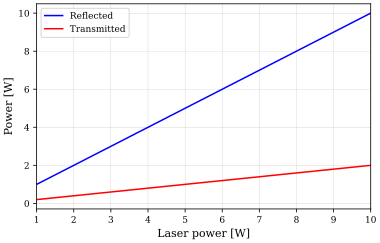

Reflected power: [ 1.    1.45  1.9   2.35  2.8   3.25  3.7   4.15  4.6   5.05  5.5   5.95
  6.4   6.85  7.3   7.75  8.2   8.65  9.1   9.55 10.  ]
Transmitted power: [0.2  0.29 0.38 0.47 0.56 0.65 0.74 0.83 0.92 1.01 1.1  1.19 1.28 1.37
 1.46 1.55 1.64 1.73 1.82 1.91 2.  ]
Total output: [ 1.2   1.74  2.28  2.82  3.36  3.9   4.44  4.98  5.52  6.06  6.6   7.14
  7.68  8.22  8.76  9.3   9.84 10.38 10.92 11.46 12.  ]


In [12]:
finesse.configure(plotting=True)
kat = finesse.Model()

kat.parse("""

    l L0 1
    s s1 L0.p1 m1.p1 L=1
    m m1 R=0.8 T=0.2 phi=0
    pd pd1 m1.p1.i
    pd pd2 m1.p2.o
""")
out = kat.run(Xaxis('L0.P', 'lin', 1, 10, 20))
plt.plot(out.x1, out['pd1'], label='Reflected')
plt.plot(out.x1, out['pd2'], label='Transmitted')
plt.xlabel('Laser power [W]')
plt.ylabel('Power [W]')
plt.legend()
plt.show()

print("Reflected power:", out['pd1'])
print("Transmitted power:", out['pd2'])
print("Total output:", out['pd1'] + out['pd2'])

# **Modelling Fabry Perot Cavity**

### **Task 1: Building the base model**

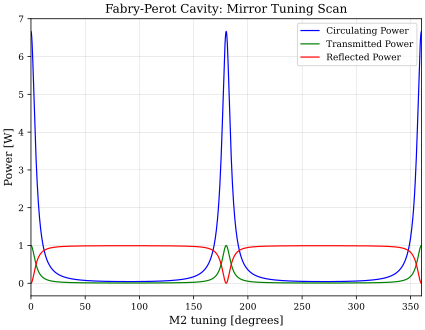

In [23]:
finesse.configure(plotting=True)

#Defining the base model
base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

#Adding the detectors
kat = base.deepcopy()
kat.parse("""
    pd Prefl M1.p1.o
    pd Pcirc M1.p2.o
    pd Ptran M2.p2.o

""")

out1 = kat.run(Xaxis("M2.phi", "lin", 0, 360, 1000)) #Scanning the phase of M2


fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(out1.x[0], out1['Pcirc'], 'b-', linewidth=1.2, label='Circulating Power')
ax.plot(out1.x[0], out1['Ptran'], 'g-', linewidth=1.2, label='Transmitted Power')
ax.plot(out1.x[0], out1['Prefl'], 'r-', linewidth=1.2, label='Reflected Power')
ax.set_ylabel('Power [W]')
ax.set_xlabel('M2 tuning [degrees]')
ax.set_title('Fabry-Perot Cavity: Mirror Tuning Scan')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### **Task 2: Simulate the response of the cavity as the laser frequency is varied**

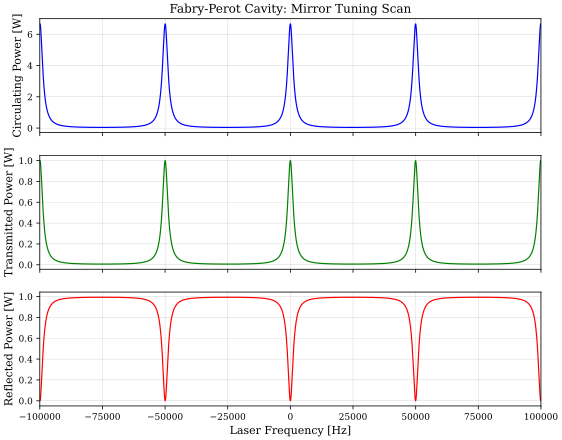

In [26]:
finesse.configure(plotting=True)

#Defining the base model
base = finesse.Model()
base.parse("""

l laser 1
s s0 laser.p1 M1.p1 L=10
m M1 R=0.85 T=0.15 phi=0
s scav M1.p2 M2.p1 L=3000
m M2 R=0.85 T=0.15 phi=0

""")

#Adding the detectors
kat = base.deepcopy()
kat.parse("""

pd Prefl M1.p1.o
pd Pcirc M1.p2.o
pd Ptran M2.p2.o

""")

out1 = kat.run(Xaxis("laser.f", "lin", -1e5, 1e5, 2500)) #Scanning the laser frequency from -100kHz to 100kHz


fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(out1.x[0], out1['Pcirc'], 'b-', linewidth=1.2)
axes[0].set_ylabel('Circulating Power [W]')
axes[0].set_title('Fabry-Perot Cavity: Mirror Tuning Scan')
axes[0].grid(True, alpha=0.3)

axes[1].plot(out1.x[0], out1['Ptran'], 'g-', linewidth=1.2)
axes[1].set_ylabel('Transmitted Power [W]')
axes[1].grid(True, alpha=0.3)

axes[2].plot(out1.x[0], out1['Prefl'], 'r-', linewidth=1.2)
axes[2].set_ylabel('Reflected Power [W]')
axes[2].set_xlabel('Laser Frequency [Hz]')
axes[2].grid(True, alpha=0.3)

plt.show()

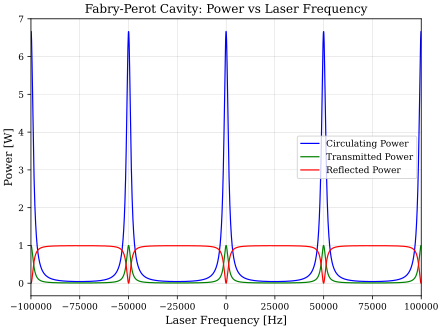

In [27]:
finesse.configure(plotting=True)

#Defining the base model
base = finesse.Model()
base.parse("""

    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0

""")

#Adding the detectors
kat = base.deepcopy()
kat.parse("""

    pd Prefl M1.p1.o
    pd Pcirc M1.p2.o
    pd Ptran M2.p2.o

""")

out1 = kat.run(Xaxis("laser.f", "lin", -1e5, 1e5, 2500)) #Scanning the laser frequency from -100kHz to 100kHz

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(out1.x[0], out1['Pcirc'], 'b-', linewidth=1.2, label='Circulating Power')
ax.plot(out1.x[0], out1['Ptran'], 'g-', linewidth=1.2, label='Transmitted Power')
ax.plot(out1.x[0], out1['Prefl'], 'r-', linewidth=1.2, label='Reflected Power')

ax.set_ylabel('Power [W]')
ax.set_xlabel('Laser Frequency [Hz]')
ax.set_title('Fabry-Perot Cavity: Power vs Laser Frequency')
ax.grid(True, alpha=0.3)

ax.legend()
plt.show()

In [ ]:
finesse.configure(plotting=True)

#Defining the base model
base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

#Adding the detectors
kat = base.deepcopy()
kat.parse("""
    pd Prefl M1.p1.o
    pd Pcirc M1.p2.o
    pd Ptran M2.p2.o

""")

out1 = kat.run(Xaxis("laser.f", "lin", -1e5, 1e5, 2500))

from scipy.signal import find_peaks
x = out1.x[0] #Extracting the laser frequency to scan
peaks, _ = find_peaks(out1['Pcirc'], height=1)

peak_freqs = x[peaks] #Retrieving the frequencies at which resonance occur

fsr_values = np.diff(peak_freqs)
fsr = np.mean(fsr_values)

print(f"Estimated FSR = {fsr:.2f} Hz")

Estimated FSR = 49960.00 Hz


**Free Spectral Range (FSR)** is the frequency spacing between adjacent resonances and is given by:

$$FSR = \frac{c}{2L}$$

For a cavity length of $L = 3000$ m:

$$FSR = \frac{3 \times 10^8}{2 \times 3000} = 50,000 \text{ Hz}$$

### **Task 3: Free Spectral Range, Full Width Half Maximum, and Finesse**

In [ ]:
from scipy.signal import find_peaks
finesse.configure(plotting=True)

#Defining the base model
base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

#Adding the detectors
kat = base.deepcopy()
kat.parse("""
    pd Prefl M1.p1.o
    pd Pcirc M1.p2.o
    pd Ptran M2.p2.o

""")

out1 = kat.run(Xaxis("laser.f", "lin", -1e5, 1e5, 40000))


x = out1.x[0] #Extracting the laser frequency
y = out1['Pcirc'] #Extracting the circulating power

peaks, _ = find_peaks(out1['Pcirc'], height=1)

peak_freqs = x[peaks]
peak = peaks[len(peaks)//2]

peak_height = y[peak]
half_max = peak_height / 2

fsr_values = np.diff(peak_freqs)
fsr = np.mean(fsr_values)

indices = np.where(y > half_max)[0]
left = indices[indices < peak][-1]
right = indices[indices > peak][0]

fwhm = x[right] - x[left]

finesse = fsr / fwhm

print(f"Estimated FSR = {fsr:.2f} Hz")
print(f"FWHM = {fwhm:.2f} Hz")
print(f"Finesse = {finesse:.2f}")

Estimated FSR = 49965.00 Hz
FWHM = 10.00 Hz
Finesse = 4996.50


1. Free Spectral Range (FSR)
The frequency spacing between adjacent resonances:
$$FSR = \frac{c}{2L}$$

2. Full Width at Half Maximum (FWHM)
* Measures the spectral width of a resonance peak.
* Indicates how sharply defined the resonance is.

3. Finesse ($F$):
$$F = \frac{FSR}{FWHM}$$


# **Simple Michelson Setup**

### **Task 1: Modelling a simple Michelson**

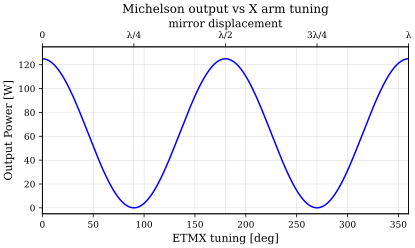

In [28]:
finesse.configure(plotting=True)

base = finesse.Model()
base.parse("""
    l laser1 P=125
    s s1 laser1.p1 bs1.p1 L=50
    bs bs1 R=0.5 T=0.5
    s armX bs1.p3 ETMX.p1 L=4000
    m ETMX R=1 T=0
    s armY bs1.p2 ETMY.p1 L=4000
    m ETMY R=1 T=0
""")

kat1 = base.deepcopy()
kat1.parse("""
    pd pow_out bs1.p4.o
""")

out = kat1.run(Xaxis("ETMX.phi", "lin", 0, 360, 1000))

fig, ax = plt.subplots()
ax.plot(out.x[0], out['pow_out'], 'b-')
ax.set_xlabel('ETMX tuning [deg]')
ax.set_ylabel('Output Power [W]')
ax.set_title('Michelson output vs X arm tuning')
ax.set_ylim(-5, 135)
ax.grid(True, alpha=0.3)

ax2 = ax.twiny()
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['0', 'λ/4', 'λ/2', '3λ/4', 'λ'])
ax2.set_xlabel('mirror displacement')

plt.tight_layout()
plt.show()

* The output power varies sinusoidally with mirror tuning.
* Bright Fringe (~125 W): Occurs when the two arms are in phase.
* Dark Fringe (~0 W): Occurs when arms are out of phase by $\pi$.


### **Task 2: Michelson interferometer response to gravitational wave signal**

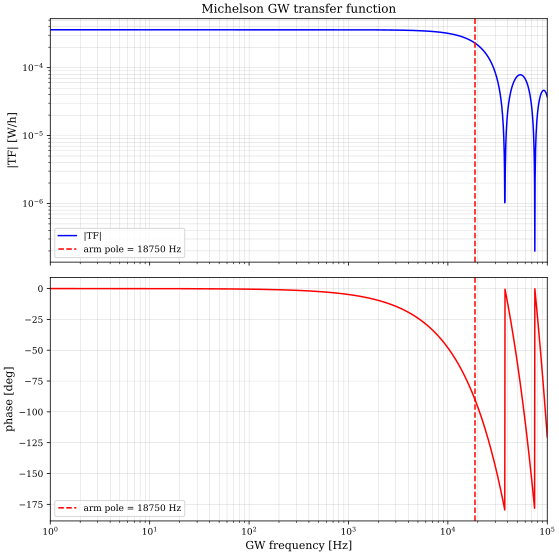

In [35]:
finesse.configure(plotting=True)

base = finesse.Model()
base.parse("""
    l laser1 P=125
    s s1 laser1.p1 bs1.p1 L=50
    bs bs1 R=0.5 T=0.5
    s armX bs1.p3 ETMX.p1 L=4000
    m ETMX R=1 T=0 phi=90
    s armY bs1.p2 ETMY.p1 L=4000
    m ETMY R=1 T=0 phi=0
""")

kat1 = base.deepcopy()
kat1.parse("""
    fsig(1)
    sgen sig_x armX.h 1 0
    sgen sig_y armY.h 1 180
    pd1 tf_out bs1.p4.o fsig.f
""")

out2 = kat1.run(Xaxis("fsig.f", "log", 1, 100000, 2000))

f         = out2.x[0]
TF        = out2['tf_out']
magnitude = np.abs(TF)
phase_deg = np.angle(TF, deg=True)

arm_pole = 3e8 / (4 * 4000)
pole_idx = np.argmin(np.abs(f - arm_pole))

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].loglog(f, magnitude, 'b-', label='|TF|')
axes[0].axvline(arm_pole, color='red', linestyle='--', label=f'arm pole = {arm_pole:.0f} Hz')
axes[0].set_ylabel('|TF| [W/h]')
axes[0].set_title('Michelson GW transfer function')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(f, phase_deg, 'r-')
axes[1].axvline(arm_pole, color='red', linestyle='--', label=f'arm pole = {arm_pole:.0f} Hz')
axes[1].set_ylabel('phase [deg]')
axes[1].set_xlabel('GW frequency [Hz]')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

I introduced a differential signal to mimic a gravitational wave and studied the frequency response.

A gravitational wave stretches one arm and squeezes the other, so the differential phase shift is:

$$\Delta \phi = \frac{4\pi}{\lambda} \Delta L$$

But light doesn't bounce between the mirrors instantaneously. Because of this delay, the detector loses sensitivity at higher frequencies. The cutoff happens at the arm pole frequency:

$$f_{\text{pole}} = \frac{c}{4L} = \frac{3 \times 10^8}{4 \times 4000} = 18{,}750 \text{ Hz}$$

From the plot, I observed that the TF magnitude is flat below arm pole frequency and drops off above it (down to $1/\sqrt{2}$ at the pole itself). Similarly, the phase shift stays pretty close to zero at low frequencies.


# **Advanced Fabry Perot Cavity**

### **Task 1: Plot the PDH error signal for the cavity**

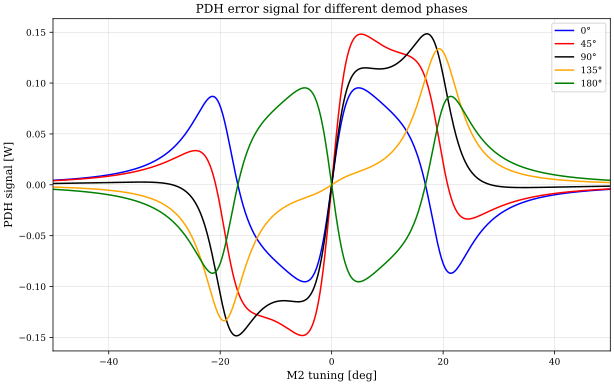

In [31]:
finesse.configure(plotting=True)

base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

demod_phases = [0, 45, 90, 135, 180]

plt.figure(figsize=(10, 6))

for demod_phase in demod_phases:
    kat = base.deepcopy()
    kat.remove(kat.s0)
    kat.parse(f"""
        s s1 laser.p1 mod.p1 L=1
        modulator mod f=80M midx=0.3 order=1
        s s2 mod.p2 M1.p1 L=9
        pd1 PDH M1.p1.o 80M {demod_phase}
    """)
    out = kat.run(Xaxis("M2.phi", "lin", -50, 50, 1000))
    plt.plot(out.x[0], out['PDH'], label=f'{demod_phase}°')

plt.xlabel("M2 tuning [deg]")
plt.ylabel("PDH signal [W]")
plt.title("PDH error signal for different demod phases")
plt.grid(True)
plt.legend()
plt.show()

I applied a phase modulation at $f_{\text{mod}} = 80 \text{ MHz}$ at the input.
* **$0^\circ, 180^\circ$:** Signal is distorted and not purely antisymmetric.
* **$45^\circ, 135^\circ$:** Intermediate behavior.
* The **$90^\circ$** case gave the cleanest antisymmetric signal, which is ideal for feedback.

### **Task 2: Plot the circulating power and PDH error signal for multiple M1 tunings**

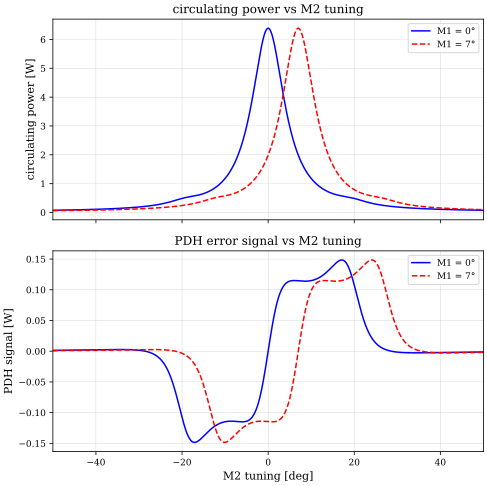

In [32]:
finesse.configure(plotting=True)

base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

kat = base.deepcopy()
kat.remove(kat.s0)
kat.parse("""
    s s1 laser.p1 mod.p1 L=1
    modulator mod f=80M midx=0.3 order=1
    s s2 mod.p2 M1.p1 L=9
    pd1 PDH M1.p1.o 80M 90
    pd Pcirc M1.p2.o
""")

out1 = kat.run(Xaxis("M2.phi", "lin", -50, 50, 1000))

kat.M1.phi = 7
out2 = kat.run(Xaxis("M2.phi", "lin", -50, 50, 1000))

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(out1.x[0], out1['Pcirc'], label="M1 = 0°")
axes[0].plot(out2.x[0], out2['Pcirc'], '--', label="M1 = 7°")
axes[0].set_ylabel("circulating power [W]")
axes[0].set_title("circulating power vs M2 tuning")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(out1.x[0], out1['PDH'], label="M1 = 0°")
axes[1].plot(out2.x[0], out2['PDH'], '--', label="M1 = 7°")
axes[1].set_ylabel("PDH signal [W]")
axes[1].set_xlabel("M2 tuning [deg]")
axes[1].set_title("PDH error signal vs M2 tuning")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

The circulating power peaks where the resonance condition is satisfied, given by:

$$2kL + \phi_1 + \phi_2 = 2\pi n$$

* At $M1 = 7^\circ$: An additional phase ($\phi_1$) is introduced. From the plot it seems $M2$ value is shifted, causing the power peak to move.
* It was interesting to see the PDH signal stay near zero while the circulating power remains high.

### **Task 3: Setting up a FP cavity that is locked so that the input mirror follows the end mirror**

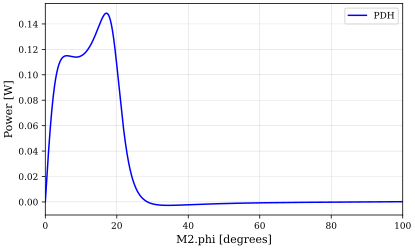

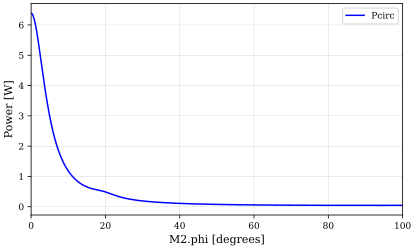

In [33]:
finesse.configure(plotting=True)

base = finesse.Model()
base.parse("""
    l laser 1
    s s0 laser.p1 M1.p1 L=10
    m M1 R=0.85 T=0.15 phi=0
    s scav M1.p2 M2.p1 L=3000
    m M2 R=0.85 T=0.15 phi=0
""")

kat = base.deepcopy()
kat.remove(kat.s0)
kat.parse("""
    s s1 laser.p1 mod.p1 L=1
    modulator mod f=80M midx=0.3 order=1
    s s2 mod.p2 M1.p1 L=9
    pd1 PDH M1.p1.o 80M 90
    pd Pcirc M1.p2.o
    lock cav_lock PDH M1.phi 1 1e-8
""")

out = kat.run(Xaxis("M2.phi", "lin", 0, 100, 1000))
out.plot()
plt.show()

 As the  feedback loop is applied to the input mirror ($M1$), it forces $M1$ to follow changes in the end mirror ($M2$) maintaining the resonance.

As $M2$ is scanned from $0^\circ$ to $100^\circ$, the lock uses the PDH error signal to dynamically adjust $M1$.
